In [26]:
import pandas as pd

df = pd.read_csv("../data/dataset-tickets-multi-lang3-4k.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4000, 17)


,subject,body,answer,type,queue,priority,language,business_type,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9
0,Problema crítico del servidor requiere atenció...,Es necesaria una investigación inmediata sobre...,Estamos investigando urgentemente el problema ...,Incident,Technical Support,high,es,IT Services,Urgent Issue,Service Disruption,Incident Report,Service Recovery,System Maintenance,NaN,NaN,NaN,NaN
1,Anfrage zur Verfügbarkeit des Dell XPS 13 9310,"Sehr geehrter Kundenservice,\n\nich hoffe, die...","Sehr geehrter <name>,\n\nvielen Dank, dass Sie...",Request,Customer Service,low,de,Tech Online Store,Sales Inquiry,Product Support,Customer Service,Order Issue,Returns and Exchanges,NaN,NaN,NaN,NaN
2,Erro na Autocompletação de Código do IntelliJ ...,"Prezado Suporte ao Cliente <name>,\n\nEstou es...","Prezado <name>,\n\nObrigado por entrar em cont...",Incident,Technical Support,high,pt,IT Services,Technical Support,Software Bug,Problem Resolution,Urgent Issue,IT Support,NaN,NaN,NaN,NaN
3,Urgent Assistance Required: AWS Service,"Dear IT Services Support Team, \n\nI am reachi...","Dear <name>,\n\nThank you for reaching out reg...",Request,IT Support,high,en,IT Services,IT Support,Urgent Issue,Service Notification,Cloud Services,Problem Resolution,Technical Guidance,Performance Tuning,NaN,NaN
4,Problème d'affichage de MacBook Air,Cher équipe de support du magasin en ligne Tec...,"Cher <name>,\n\nMerci de nous avoir contactés ...",Incident,Product Support,low,fr,Tech Online Store,Technical Support,Product Support,Hardware Failure,Service Recovery,Routine Request,NaN,NaN,NaN,NaN


In [27]:
import pandas as pd

df = pd.read_csv("../data/dataset-tickets-multi-lang3-4k.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4000, 17)


,subject,body,answer,type,queue,priority,language,business_type,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9
0,Problema crítico del servidor requiere atenció...,Es necesaria una investigación inmediata sobre...,Estamos investigando urgentemente el problema ...,Incident,Technical Support,high,es,IT Services,Urgent Issue,Service Disruption,Incident Report,Service Recovery,System Maintenance,NaN,NaN,NaN,NaN
1,Anfrage zur Verfügbarkeit des Dell XPS 13 9310,"Sehr geehrter Kundenservice,\n\nich hoffe, die...","Sehr geehrter <name>,\n\nvielen Dank, dass Sie...",Request,Customer Service,low,de,Tech Online Store,Sales Inquiry,Product Support,Customer Service,Order Issue,Returns and Exchanges,NaN,NaN,NaN,NaN
2,Erro na Autocompletação de Código do IntelliJ ...,"Prezado Suporte ao Cliente <name>,\n\nEstou es...","Prezado <name>,\n\nObrigado por entrar em cont...",Incident,Technical Support,high,pt,IT Services,Technical Support,Software Bug,Problem Resolution,Urgent Issue,IT Support,NaN,NaN,NaN,NaN
3,Urgent Assistance Required: AWS Service,"Dear IT Services Support Team, \n\nI am reachi...","Dear <name>,\n\nThank you for reaching out reg...",Request,IT Support,high,en,IT Services,IT Support,Urgent Issue,Service Notification,Cloud Services,Problem Resolution,Technical Guidance,Performance Tuning,NaN,NaN
4,Problème d'affichage de MacBook Air,Cher équipe de support du magasin en ligne Tec...,"Cher <name>,\n\nMerci de nous avoir contactés ...",Incident,Product Support,low,fr,Tech Online Store,Technical Support,Product Support,Hardware Failure,Service Recovery,Routine Request,NaN,NaN,NaN,NaN


In [28]:
print("Ticket Type:")
print(df["type"].value_counts())

print("\nTicket Priority:")
print(df["priority"].value_counts())

Ticket Type:
type
Incident    1608
Request     1097
Problem      853
Change       442
Name: count, dtype: int64

Ticket Priority:
priority
high      1649
medium    1603
low        748
Name: count, dtype: int64


In [29]:
df["text"] = (
    df["subject"].fillna("") + " " +
    df["body"].fillna("")
)

df["text"] = (
    df["text"]
    .str.lower()
    .str.replace(r"[^a-zA-Z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df[["text", "type", "priority"]].head()

,text,type,priority
0,problema cr tico del servidor requiere atenci ...,Incident,high
1,anfrage zur verf gbarkeit des dell xps 13 9310...,Request,low
2,erro na autocompleta o de c digo do intellij i...,Incident,high
3,urgent assistance required aws service dear it...,Request,high
4,probl me d affichage de macbook air cher quipe...,Incident,low


In [30]:
from sklearn.model_selection import train_test_split

X = df["text"]
y_type = df["type"]
y_priority = df["priority"]

X_train, X_test, y_type_train, y_type_test = train_test_split(
    X,
    y_type,
    test_size=0.2,
    random_state=42,
    stratify=y_type
)

_, _, y_priority_train, y_priority_test = train_test_split(
    X,
    y_priority,
    test_size=0.2,
    random_state=42,
    stratify=y_priority
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 3200
Testing samples: 800


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (3200, 10000)
Testing TF-IDF shape: (800, 10000)


In [32]:
from sklearn.linear_model import LogisticRegression

type_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

type_model.fit(X_train_tfidf, y_type_train)

print("Ticket Type model trained successfully!")

Ticket Type model trained successfully!


In [33]:
from sklearn.metrics import accuracy_score, classification_report

y_type_pred = type_model.predict(X_test_tfidf)

print("Ticket Type Accuracy:", accuracy_score(y_type_test, y_type_pred))
print("\nClassification Report:")
print(classification_report(y_type_test, y_type_pred))

Ticket Type Accuracy: 0.62375

Classification Report:
              precision    recall  f1-score   support

      Change       0.89      0.38      0.53        88
    Incident       0.59      0.83      0.69       322
     Problem       0.53      0.19      0.28       171
     Request       0.66      0.76      0.70       219

    accuracy                           0.62       800
   macro avg       0.67      0.54      0.55       800
weighted avg       0.63      0.62      0.59       800



In [34]:
priority_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

priority_model.fit(X_train_tfidf, y_priority_train)

print("Priority model trained successfully!")

Priority model trained successfully!


In [35]:
y_priority_pred = priority_model.predict(X_test_tfidf)

print("Priority Accuracy:", accuracy_score(y_priority_test, y_priority_pred))
print("\nClassification Report:")
print(classification_report(y_priority_test, y_priority_pred))

Priority Accuracy: 0.385

Classification Report:
              precision    recall  f1-score   support

        high       0.45      0.43      0.44       330
         low       0.23      0.25      0.24       150
      medium       0.40      0.40      0.40       320

    accuracy                           0.39       800
   macro avg       0.36      0.36      0.36       800
weighted avg       0.39      0.39      0.39       800



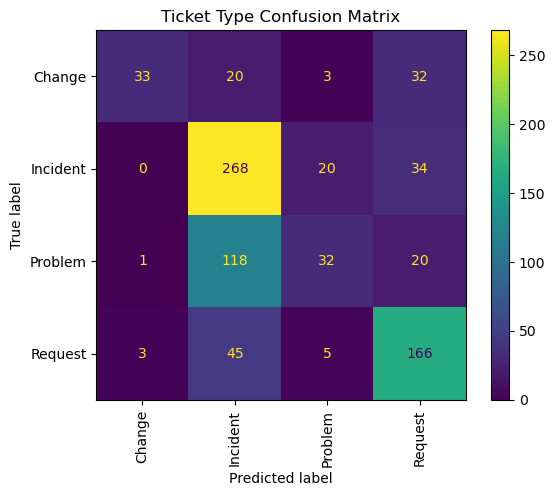

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_type_test,
    y_type_pred,
    xticks_rotation="vertical"
)

plt.title("Ticket Type Confusion Matrix")
plt.show()

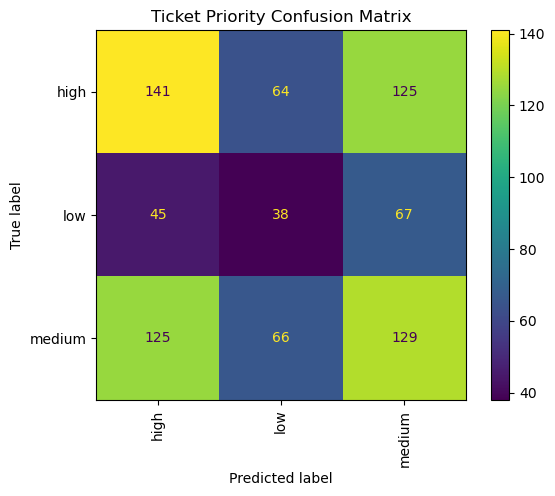

In [37]:
ConfusionMatrixDisplay.from_predictions(
    y_priority_test,
    y_priority_pred,
    xticks_rotation="vertical"
)

plt.title("Ticket Priority Confusion Matrix")
plt.show()

In [38]:
new_ticket = [
    "AWS server is down and our production service is unavailable. "
    "This is urgent and needs immediate attention."
]

new_ticket_tfidf = vectorizer.transform(new_ticket)

print("Predicted Type:", type_model.predict(new_ticket_tfidf)[0])
print("Predicted Priority:", priority_model.predict(new_ticket_tfidf)[0])

Predicted Type: Incident
Predicted Priority: low


In [39]:
from sklearn.svm import LinearSVC

# Ticket Type model
type_svm = LinearSVC(random_state=42)
type_svm.fit(X_train_tfidf, y_type_train)

# Priority model
priority_svm = LinearSVC(
    random_state=42,
    class_weight="balanced"
)
priority_svm.fit(X_train_tfidf, y_priority_train)

# Predictions
y_type_svm_pred = type_svm.predict(X_test_tfidf)
y_priority_svm_pred = priority_svm.predict(X_test_tfidf)

# Results
print("Ticket Type Accuracy:",
      accuracy_score(y_type_test, y_type_svm_pred))

print("Priority Accuracy:",
      accuracy_score(y_priority_test, y_priority_svm_pred))

print("\n--- Ticket Type ---")
print(classification_report(y_type_test, y_type_svm_pred))

print("\n--- Priority ---")
print(classification_report(y_priority_test, y_priority_svm_pred))

Ticket Type Accuracy: 0.62375
Priority Accuracy: 0.37625

--- Ticket Type ---
              precision    recall  f1-score   support

      Change       0.77      0.58      0.66        88
    Incident       0.62      0.73      0.67       322
     Problem       0.45      0.32      0.38       171
     Request       0.67      0.72      0.70       219

    accuracy                           0.62       800
   macro avg       0.63      0.59      0.60       800
weighted avg       0.62      0.62      0.61       800


--- Priority ---
              precision    recall  f1-score   support

        high       0.43      0.42      0.42       330
         low       0.20      0.18      0.19       150
      medium       0.40      0.42      0.41       320

    accuracy                           0.38       800
   macro avg       0.34      0.34      0.34       800
weighted avg       0.37      0.38      0.37       800



In [40]:
new_ticket_tfidf = vectorizer.transform(new_ticket)

print("Predicted Type:",
      type_svm.predict(new_ticket_tfidf)[0])

print("Predicted Priority:",
      priority_svm.predict(new_ticket_tfidf)[0])

Predicted Type: Incident
Predicted Priority: medium


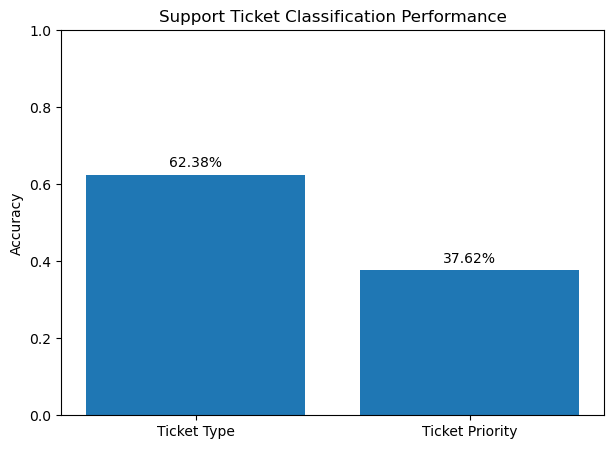

In [41]:
import matplotlib.pyplot as plt

results = {
    "Ticket Type": accuracy_score(y_type_test, y_type_svm_pred),
    "Ticket Priority": accuracy_score(y_priority_test, y_priority_svm_pred)
}

plt.figure(figsize=(7, 5))
plt.bar(results.keys(), results.values())

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Support Ticket Classification Performance")

for i, value in enumerate(results.values()):
    plt.text(i, value + 0.02, f"{value:.2%}", ha="center")

plt.show()